# notebooks/03_model_building.ipynb

In [2]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

## Load Model-Ready Data

In [3]:
DATA_PATH = os.path.join('..', 'data', 'panel_data_model_ready.parquet')

df = pd.read_parquet(DATA_PATH)
print(f'Data Shape: {df.shape}')
display(df.head())

Data Shape: (153515, 17)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                               
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909   3.771960   
           AMGN   2.460476  5.177506      5.177506       5.177506   3.635898   
           AMZN   5.818162  9.886836      9.886836       9.886836   8.018926   
           AXP    4.693210  4.448244      4.448244       4.448244   4.122573   
           BA     2.934207  7.469396      7.469396       7.469396   7.016747   

                  good_lag_1  bad_lag_1    rq_lag_1  vix_lag_1  \
Date       Stock                                                 
2003-01-03 AAPL     5.102315   1.391595  152.729402      25.39   
           AMGN     3.362921   1.814585   46.168213      25.39   
           AMZN     6.074276   3.812559  200.751309      25.39   
           AXP      3.337253   1.110991  114.695371      25.39   
           BA       5.107386   2.362010  150.112379      25.39   

                  bad_good_ratio_lag_1  jump_ratio_lag_1  
Date       Stock                                          
2003-01-03 AAPL               0.272738          0.419154  
           AMGN               0.539586          0.297751  
           AMZN               0.627656          0.188929  
           AXP                0.332906          0.073213  
           BA                 0.462469          0.060600

## Define Features (X) and Target (Y)

In [4]:
Y = df['Y_reg']

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]

X_advanced = df.drop(columns=['rv', 'bpv', 'good', 'bad', 'rq', 'vix', 'Y_reg'])

print(f'Target (Y) shape: {Y.shape}')
print(f'HAR Features (X_har) shape: {X_har.shape}')
print(f'Advanced Features (X_advanced) shape: {X_advanced.shape}')
display(X_har.head())

Target (Y) shape: (153515,)
HAR Features (X_har) shape: (153515, 3)
Advanced Features (X_advanced) shape: (153515, 10)


rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2003-01-03 AAPL   6.493909      6.493909       6.493909
           AMGN   5.177506      5.177506       5.177506
           AMZN   9.886836      9.886836       9.886836
           AXP    4.448244      4.448244       4.448244
           BA     7.469396      7.469396       7.469396

## Setup Rolling Window Validation

Initialized TimeSeriesSplit with 5 splits.


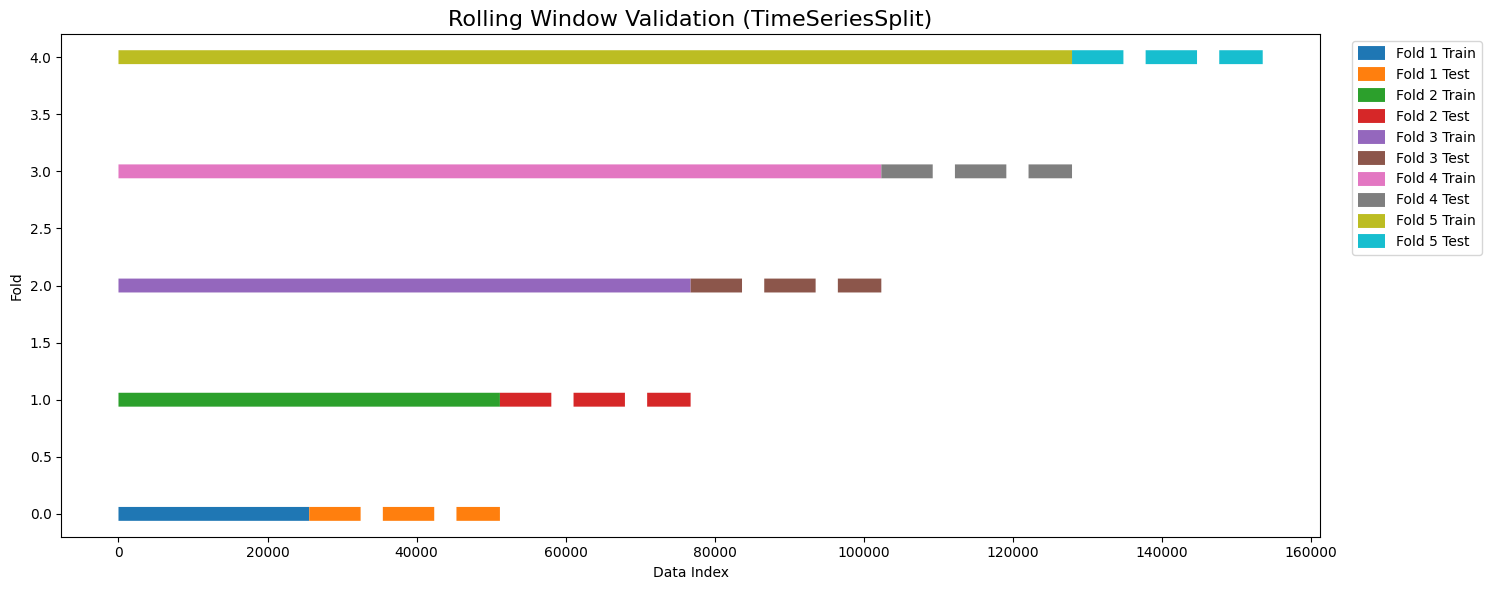

In [7]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'Initialized TimeSeriesSplit with {N_SPLITS} splits.')

fig, ax = plt.subplots(figsize=(15, 6))
for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    ax.plot(train_index, [i] * len(train_index), label=f'Fold {i+1} Train', lw=10, solid_capstyle='butt')
    ax.plot(test_index, [i] * len(test_index), label=f'Fold {i+1} Test', lw=10, ls='--', solid_capstyle='butt')

ax.set_title('Rolling Window Validation (TimeSeriesSplit)', fontsize=16)
ax.set_xlabel('Data Index')
ax.set_ylabel('Fold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train & Evaluate HAR Baseline

In [8]:
har_mse_scores = []
har_models = []

print('Training & Evaluation for HAR...')

for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_har.iloc[train_index], X_har.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    har_model = LinearRegression()
    har_model.fit(X_train, y_train)
    
    y_pred = har_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    har_mse_scores.append(mse)
    har_models.append(har_model)
    
    print(f"  Fold {i+1} MSE: {mse:.6f}")
    
average_har_mse = np.mean(har_mse_scores)
print(f"Average HAR Model MSE across all {N_SPLITS} folds: {average_har_mse:.6f}")

Training & Evaluation for HAR...
--- Fold 1/5 ---
  Train size: 25590, Test size: 25585
  Fold 1 MSE: 68.339775
--- Fold 2/5 ---
  Train size: 51175, Test size: 25585
  Fold 2 MSE: 2.732427
--- Fold 3/5 ---
  Train size: 76760, Test size: 25585
  Fold 3 MSE: 7.711325
--- Fold 4/5 ---
  Train size: 102345, Test size: 25585
  Fold 4 MSE: 23.424113
--- Fold 5/5 ---
  Train size: 127930, Test size: 25585
  Fold 5 MSE: 5.622599
Average HAR Model MSE across all 5 folds: 21.566048


In [9]:
import joblib
MODEL_PATH = os.path.join("..", "models")

final_har_model = har_models[-1]
har_model_filename = os.path.join(MODEL_PATH, "har_baseline_model.joblib")
joblib.dump(final_har_model, har_model_filename)

print(f"Final HAR model saved to: {har_model_filename}")

Final HAR model saved to: ../models/har_baseline_model.joblib
